<a href="https://colab.research.google.com/github/mohamed0barhoomi/checkpoint_data/blob/main/checkpoit_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

from tensorflow.keras import models,datasets,layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [2]:
(x_train,y_train),(x_test,y_test)=datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [4]:
x_train,x_test=x_train.reshape(-1,28,28,1)/255.0,x_test.reshape(-1,28,28,1)/255.0

In [5]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot']

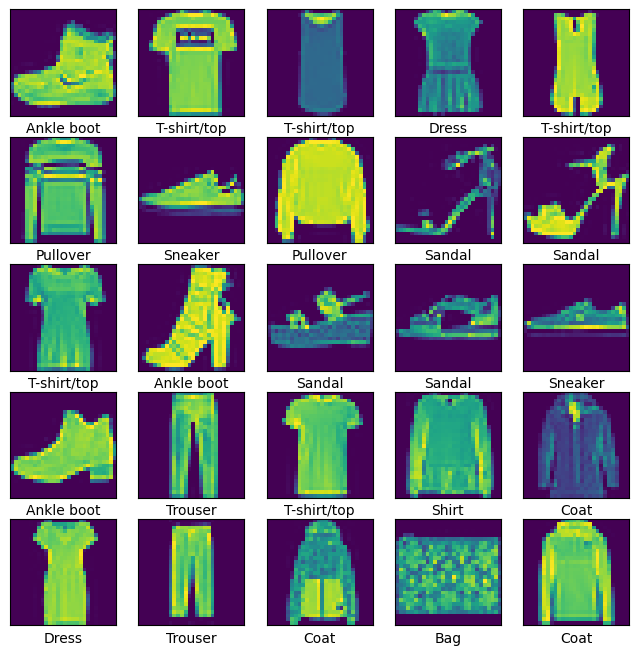

In [6]:
plt.figure(figsize=(8,8))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i]])

plt.show()

In [7]:
model=models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)))
model.add(layers.MaxPool2D(2,2))
model.add(layers.Conv2D(64,(3,3),activation="relu"))
model.add(layers.MaxPool2D(2,2))
model.add(layers.Conv2D(64,(3,3),activation="relu"))
model.add(layers.MaxPool2D(2,2))
model.add(layers.Flatten())
model.add(layers.Dense(32,activation="relu"))
model.add(layers.Dense(10,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,154 (227.16 KB)

 Trainable params: 58,154 (227.16 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
history = model.fit(x_train,y_train,epochs=40,batch_size=32,validation_data=(x_test,y_test),validation_split=0.2)

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.7732 - loss: 0.6157 - val_accuracy: 0.7906 - val_loss: 0.5415
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8455 - loss: 0.4235 - val_accuracy: 0.8477 - val_loss: 0.4186
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8672 - loss: 0.3658 - val_accuracy: 0.8648 - val_loss: 0.3808
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8809 - loss: 0.3272 - val_accuracy: 0.8660 - val_loss: 0.3704
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8911 - loss: 0.2961 - val_accuracy: 0.8753 - val_loss: 0.3463
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8983 - loss: 0.2754 - val_accuracy: 0.8787 - val_loss: 0.3288
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9037 - loss: 0.2556 - val_accuracy: 0.8731 - val_loss: 0.3462
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9122 - loss: 0.237

KeyboardInterrupt: 

In [11]:
loss,accurcy=model.evaluate(x_test,y_test)
print(accurcy)
print(loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8929 - loss: 0.4171
0.8928999900817871
0.4171483814716339


In [13]:
plt.figure()
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend(loc='upper left')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()
plt.figure()
plt.plot(history.history['accuracy'], label='train_accurcay')
plt.plot(history.history['val_accuracy'], label='val_accurcy')
plt.legend(loc='upper left')
plt.title("accurcy")
plt.xlabel("Epochs")
plt.ylabel("accuracy")
plt.grid()
plt.show()

NameError: name 'history' is not defined

<Figure size 640x480 with 0 Axes>

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[9 2 1 ... 8 1 5]


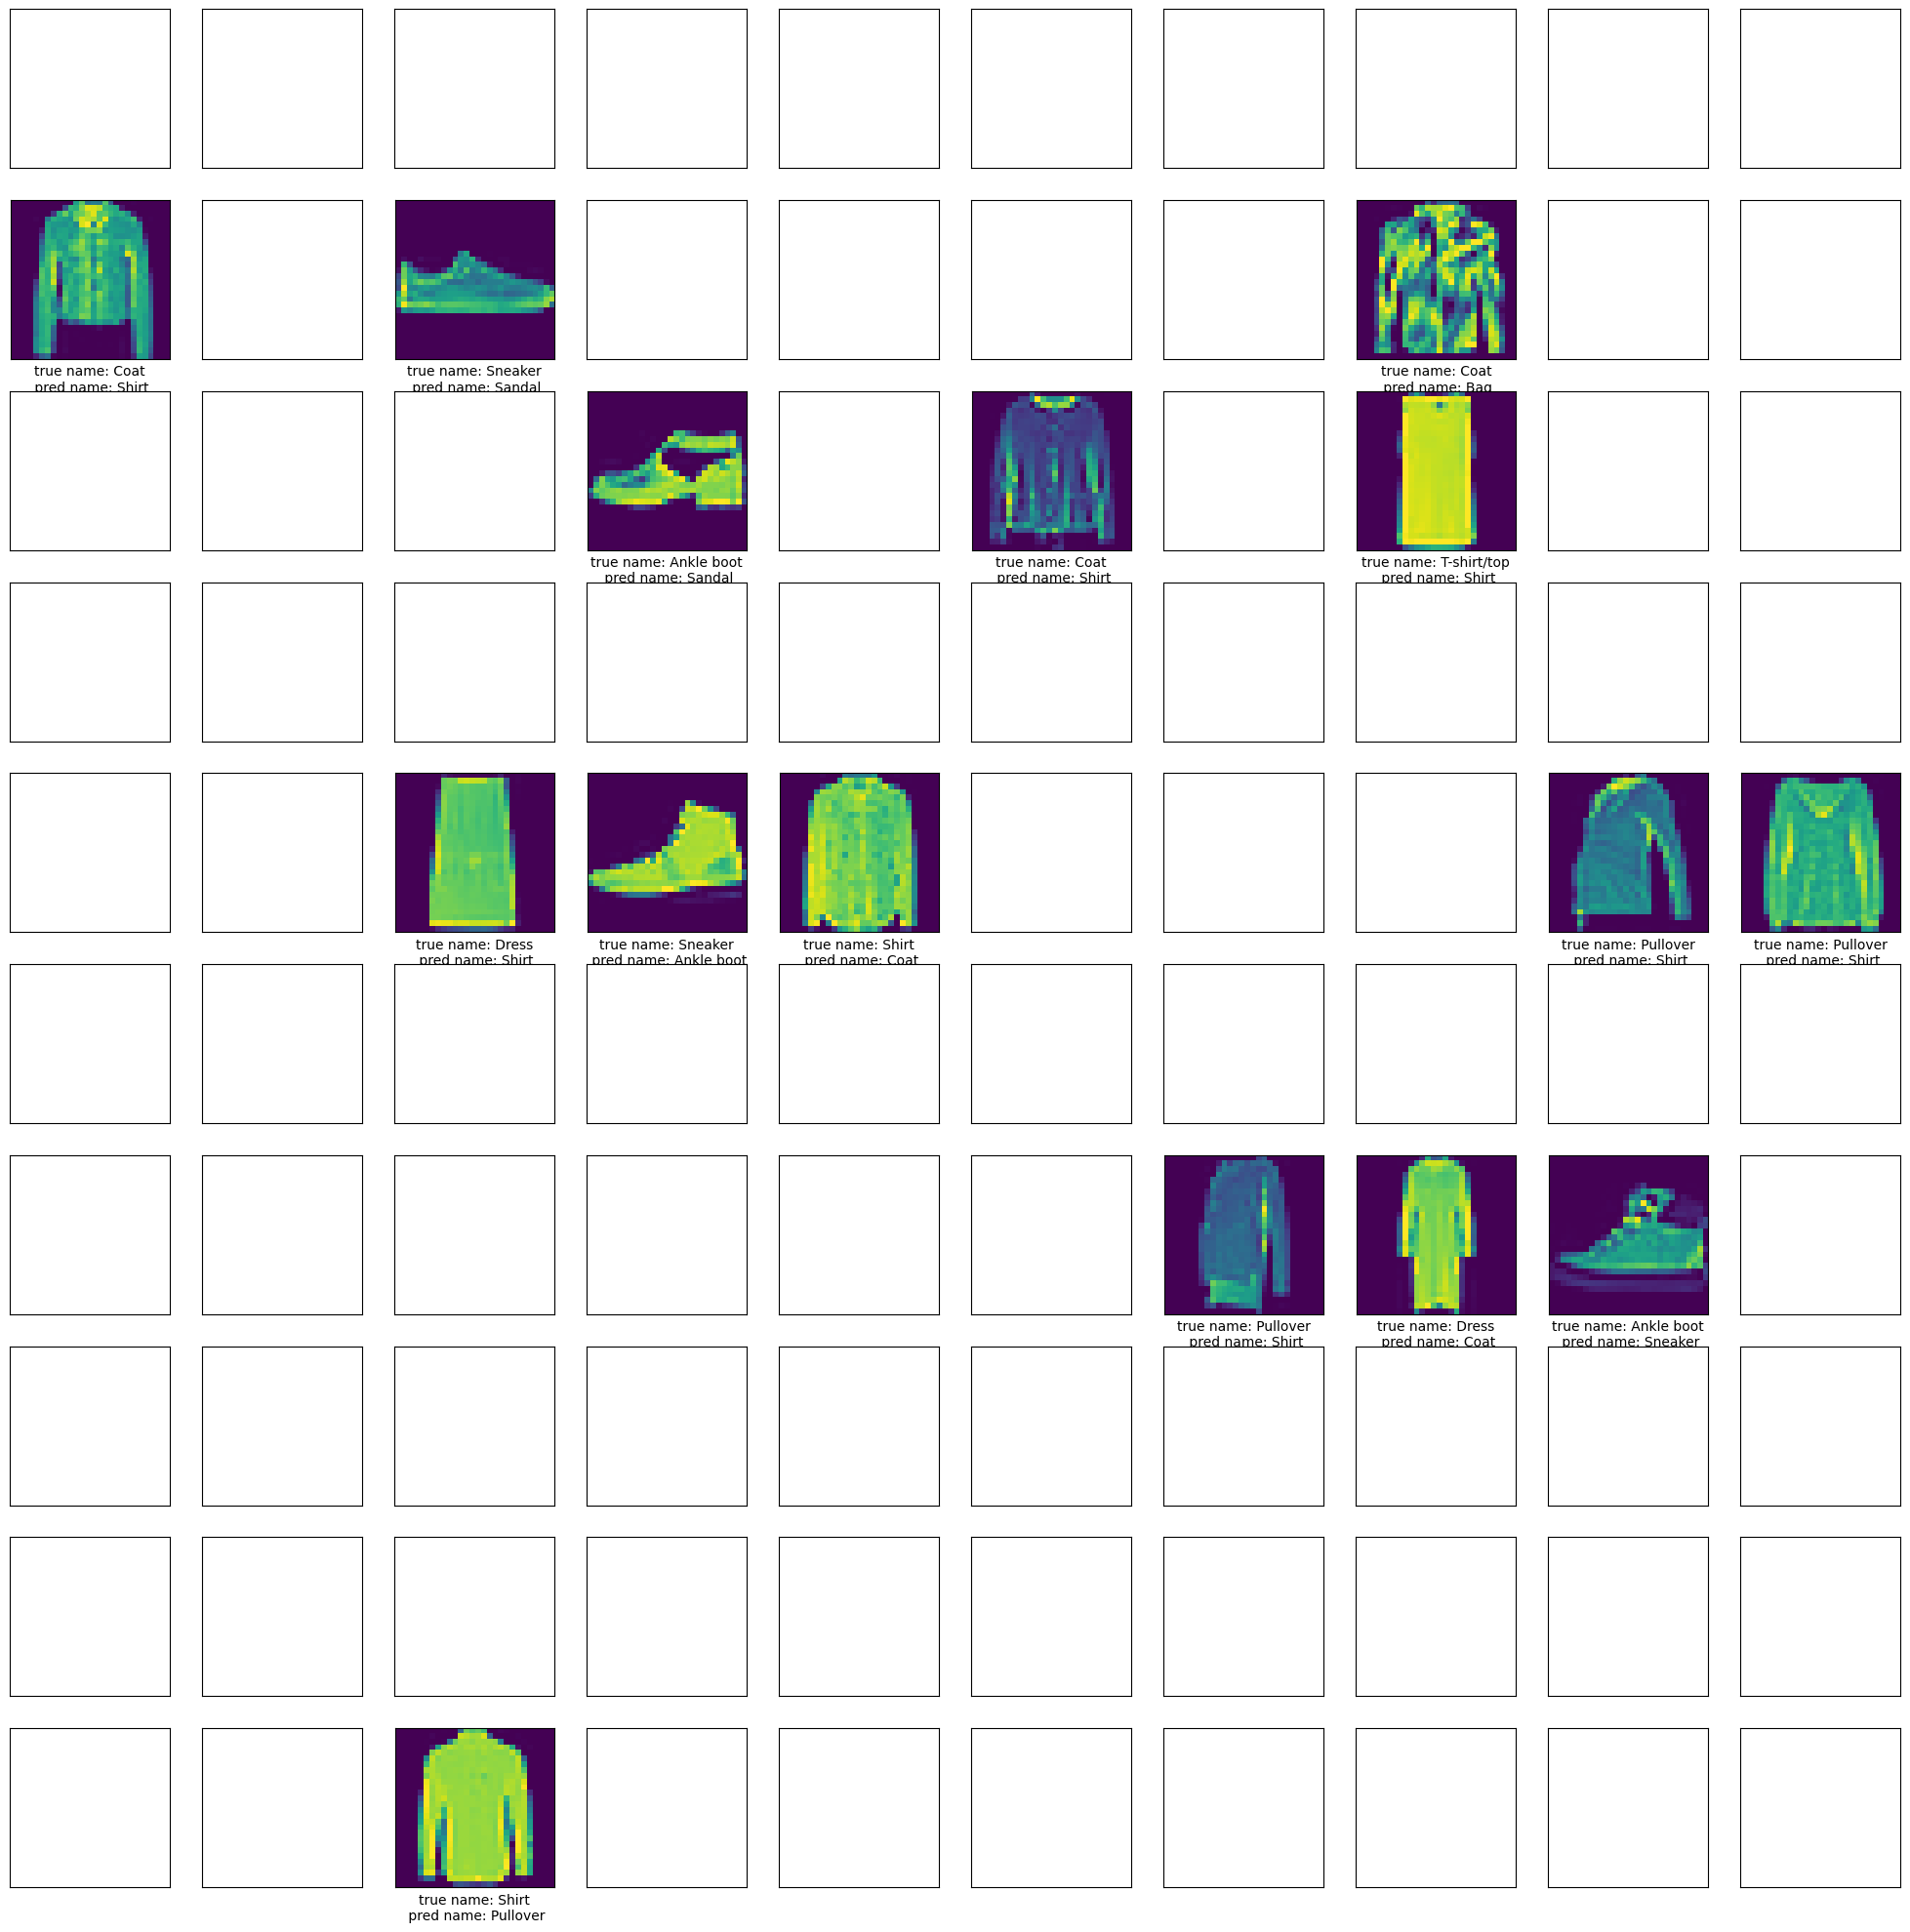

In [14]:
pred=model.predict(x_test)
pred=np.argmax(pred,axis=1)
print(pred)
sum=0
plt.figure(figsize=(25,25))
for i in range(100):
    plt.subplot(10,10,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    if(class_names[y_test[i]]!=class_names[pred[i]]):
      plt.imshow(x_test[i])
      plt.xlabel("true name: {}\n pred name: {}".format(class_names[y_test[i]],class_names[pred[i]]))
      sum+=1


plt.show()


In [15]:
print("nb erreur : {} %".format(sum))

nb erreur : 15 %


In [16]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1000
           1       0.98      0.97      0.98      1000
           2       0.81      0.86      0.84      1000
           3       0.90      0.89      0.89      1000
           4       0.83      0.84      0.84      1000
           5       0.97      0.98      0.97      1000
           6       0.72      0.68      0.70      1000
           7       0.92      0.97      0.95      1000
           8       0.96      0.97      0.97      1000
           9       0.98      0.92      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [17]:
modification=ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2
)
modification.fit(x_train)

In [20]:
model_perfect=models.Sequential()


model_perfect.add(layers.Conv2D(64,(3,3),activation="relu",input_shape=(28,28,1)))
model_perfect.add(layers.BatchNormalization())
model_perfect.add(layers.MaxPool2D(2,2))
model_perfect.add(layers.Dropout(0.25))


model_perfect.add(layers.Conv2D(128,(3,3),activation="relu",input_shape=(28,28,1)))
model_perfect.add(layers.BatchNormalization())
model_perfect.add(layers.MaxPool2D(2,2))
model_perfect.add(layers.Dropout(0.25))


# model_perfect.add(layers.Conv2D(128,(3,3),activation="relu",input_shape=(28,28,1)))
# model_perfect.add(layers.BatchNormalization())
# model_perfect.add(layers.MaxPool2D(2,2))
# model_perfect.add(layers.Dropout(0.25))


model_perfect.add(layers.Conv2D(64,(3,3),activation="relu",input_shape=(28,28,1)))
model_perfect.add(layers.BatchNormalization())
model_perfect.add(layers.MaxPool2D(2,2))
model_perfect.add(layers.Dropout(0.25))


model_perfect.add(layers.Flatten())
model_perfect.add(layers.Dense(64,activation="relu"))
model_perfect.add(layers.Dropout(0.5))
model_perfect.add(layers.Dense(10,activation="softmax"))

In [21]:
for layer in model_perfect.layers[:3]:
    layer.trainable = False

In [22]:
model_perfect.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
history_perf=model_perfect.fit(modification.flow(x_train,y_train,batch_size=22),epochs=40,validation_data=(x_test,y_test))

Epoch 1/40
2433/2728 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3953 - loss: 1.6985

KeyboardInterrupt: 

In [ ]:
loss_perf,accurcy_perf=model_perfect.evaluate(x_test,y_test)
print("accrucy = {} \n loss = {} ".format(accurcy_perf,loss_perf))

In [ ]:
plt.figure()
plt.plot(history_perf.history['loss'],label='train_loss')
plt.plot(history_perf.history['val_loss'],label='val_loss')
plt.legend(loc='upper left')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()
plt.figure()
plt.plot(history_perf.history['accuracy'], label='train_accurcay')
plt.plot(history_perf.history['val_accuracy'], label='val_accurcy')
plt.legend(loc='upper left')
plt.title("accurcy")
plt.xlabel("Epochs")
plt.ylabel("accuracy")
plt.grid()
plt.show()

In [ ]:
pred=model_perfect.predict(x_test)
pred=np.argmax(pred,axis=1)
print(pred)
sum=0
plt.figure(figsize=(25,25))
for i in range(100):
    plt.subplot(10,10,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    if(class_names[y_test[i]]!=class_names[pred[i]]):
      plt.imshow(x_test[i])
      plt.xlabel("true name: {}\n pred name: {}".format(class_names[y_test[i]],class_names[pred[i]]))
      sum+=1


plt.show()

In [ ]:
print("nauv nb d'erreur : {} %".format(sum))

In [ ]:
plt.figure()
plt.plot(history_perf.history['loss'],label='train_loss_perf')
plt.plot(history.history['loss'],label='train_loss')
plt.legend(loc='upper left')
plt.title("train: perfect_loss vs normal_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()
plt.figure()
plt.figure()
plt.plot(history_perf.history['val_loss'],label='val_loss_perf')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend(loc='upper left')
plt.title("val : perfect_loss vs normal_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()
plt.figure()

print()

In [ ]:
print(classification_report(y_test, pred))

In [ ]:
print("perfect accurcy : {} || normal accuracy : {} \n perfect loss : {}   || normal loss : {} ".format(accurcy_perf,accurcy,loss_perf,loss))

In [24]:
import pickle
with open ("fachion_model.pkl","wb") as model_file:
  pickle.dump(model,model_file)